This notebook details a CNN architecture for exoplanet classification. It was implemented as a project for CSE 576 at the University of Michigan. It was run on colab, using data from the TESS flux curve database.



In [28]:
import torch
import numpy as np
import h5py
from torch.utils.data import Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
class TessH5Dataset(Dataset):
    def __init__(self, h5_path, augment=False):
        self.f = h5py.File(h5_path, "r")
        self.global_flux  = self.f["global_flux_view_fluxnorm"]
        self.global_centr = self.f["global_centr_view"]
        self.local_flux   = self.f["local_flux_view_fluxnorm"]
        self.local_centr  = self.f["local_centr_view"]
        self.labels       = self.f["label"]
        self.N = self.labels.shape[0]


    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        g_flux = self.global_flux[idx]
        g_cent = self.global_centr[idx]
        l_flux = self.local_flux[idx]
        l_cent = self.local_centr[idx]
        label  = self.labels[idx]

        sample = {
            "global_flux": torch.tensor(g_flux, dtype=torch.float32),
            "global_cent": torch.tensor(g_cent, dtype=torch.float32),
            "local_flux":  torch.tensor(l_flux, dtype=torch.float32),
            "local_cent":  torch.tensor(l_cent, dtype=torch.float32)
        }

        return sample, torch.tensor(label, dtype=torch.long)

In [30]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

planet_class_id = 1

folder_path = "drive/MyDrive/Exoplanet Detection/"
train_ds = TessH5Dataset(folder_path + "tess_lightcurves_not_unk.h5")

labels = train_ds.labels[:]


N = len(labels)
all_indices = np.arange(N)

train_idx, temp_idx, _, temp_labels = train_test_split(
    all_indices,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

train_ds_split = Subset(train_ds, train_idx)
val_ds = Subset(train_ds, val_idx)
test_ds = Subset(train_ds, test_idx)

train_loader = DataLoader(train_ds_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

In [31]:

label_counts = {}
for batch_x, batch_y in train_loader:
    for label in batch_y:
        if label.item() not in label_counts:
            label_counts[label.item()] = 0
        label_counts[label.item()] += 1

print(label_counts)
for label in label_counts:
     print(label_counts[label] / (label_counts[0] + label_counts[1]))



label_counts = {}
for batch_x, batch_y in test_loader:
    for label in batch_y:
        if label.item() not in label_counts:
            label_counts[label.item()] = 0
        label_counts[label.item()] += 1

print(label_counts)
for label in label_counts:
     print(label_counts[label] / (label_counts[0] + label_counts[1]))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{0: 37428, 1: 2585}
0.9353959963012021
0.06460400369879789
{0: 8021, 1: 554}
0.9353935860058309
0.0646064139941691


In [53]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 37, 256) # Adjusted size based on actual input dimension
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model re-initialized with corrected fc1 layer and moved to {device}")
print("Loss function (CrossEntropyLoss) and optimizer (Adam with lr=0.001) defined.")

num_epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (sample, labels) in enumerate(train_loader):
        inputs = sample["global_flux"].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for sample, labels in val_loader:
            inputs = sample["global_flux"].to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

print("Training complete.")

Model re-initialized with corrected fc1 layer and moved to cpu
Loss function (CrossEntropyLoss) and optimizer (Adam with lr=0.001) defined.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch [1/10], Loss: 0.1429, Validation Accuracy: 95.87%
Epoch [2/10], Loss: 0.1139, Validation Accuracy: 93.66%
Epoch [3/10], Loss: 0.0981, Validation Accuracy: 93.55%
Epoch [4/10], Loss: 0.0961, Validation Accuracy: 94.55%
Epoch [5/10], Loss: 0.0886, Validation Accuracy: 93.62%
Epoch [6/10], Loss: 0.0831, Validation Accuracy: 96.58%
Epoch [7/10], Loss: 0.0784, Validation Accuracy: 96.71%
Epoch [8/10], Loss: 0.0747, Validation Accuracy: 96.37%
Epoch [9/10], Loss: 0.0690, Validation Accuracy: 96.96%
Epoch [10/10], Loss: 0.0654, Validation Accuracy: 96.20%
Training complete.


<Figure size 800x600 with 0 Axes>

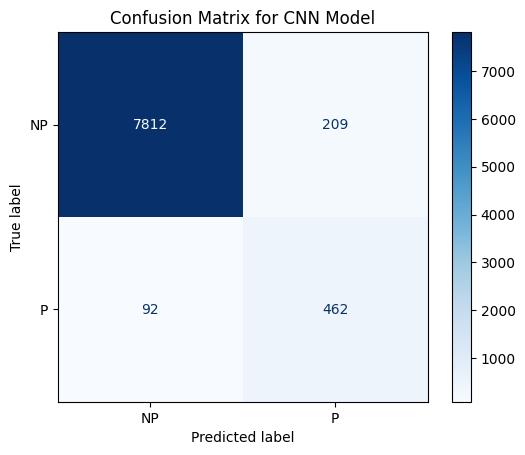

Confusion matrix generated and plotted.


In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_labels = ['NP', 'P']

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for CNN Model')
plt.show()

print("Confusion matrix generated and plotted.")

In [57]:
import torch.optim as optim
import wandb # Import wandb
import torch.nn as nn
import torch.nn.functional as F
wandb.init(project="exoplanet-detection-cnn", name="CNN_Training_Run")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

wandb.watch(model, log="all")


wandb.config.lr = 0.001
wandb.config.batch_size = 32
wandb.config.num_epochs = 10

print(f"Model moved to {device}")
print("Weights & Biases initialized and model watching enabled.")

Model moved to cpu
Weights & Biases initialized and model watching enabled.


In [62]:
from sklearn.metrics import recall_score, precision_score, precision_recall_curve, auc
import numpy as np

all_labels_array = np.array(all_labels)
all_probabilities_array = np.array(all_probabilities)

accuracy = 100 * np.sum(np.array(all_predictions) == all_labels_array) / len(all_labels_array)

recall_p = recall_score(all_labels_array, all_predictions, pos_label=1)
precision_p = precision_score(all_labels_array, all_predictions, pos_label=1)
precision_pr_p, recall_pr_p, _ = precision_recall_curve(all_labels_array, all_probabilities_array, pos_label=1)
auc_pr_p = auc(recall_pr_p, precision_pr_p)

inverted_labels_np = 1 - all_labels_array
probabilities_np = 1 - all_probabilities_array

recall_np = recall_score(inverted_labels_np, 1 - np.array(all_predictions), pos_label=1)
precision_np = precision_score(inverted_labels_np, 1 - np.array(all_predictions), pos_label=1)
precision_pr_np, recall_pr_np, _ = precision_recall_curve(inverted_labels_np, probabilities_np, pos_label=1)
auc_pr_np = auc(recall_pr_np, precision_pr_np)

print(f"Overall Performance")
print(f"Accuracy on Test Data: {accuracy:.2f}%")

print(f"\nMetrics for 'Planet' (label 1)")
print(f"Recall: {recall_p:.2f}")
print(f"Precision: {precision_p:.2f}")
print(f"AUC-PR: {auc_pr_p:.2f}")

print(f"\nMetrics for 'Non-Planet' (label 0)")
print(f"Recall: {recall_np:.2f}")
print(f"Precision: {precision_np:.2f}")
print(f"AUC-PR: {auc_pr_np:.2f}")

print("Model evaluation complete. All metrics printed.")

--- Overall Performance ---
Accuracy on Test Data: 96.49%

--- Metrics for 'Planet' (label 1) ---
Recall: 0.83
Precision: 0.69
AUC-PR: 0.82

--- Metrics for 'Non-Planet' (label 0) ---
Recall: 0.97
Precision: 0.99
AUC-PR: 1.00
Model evaluation complete. All metrics printed.


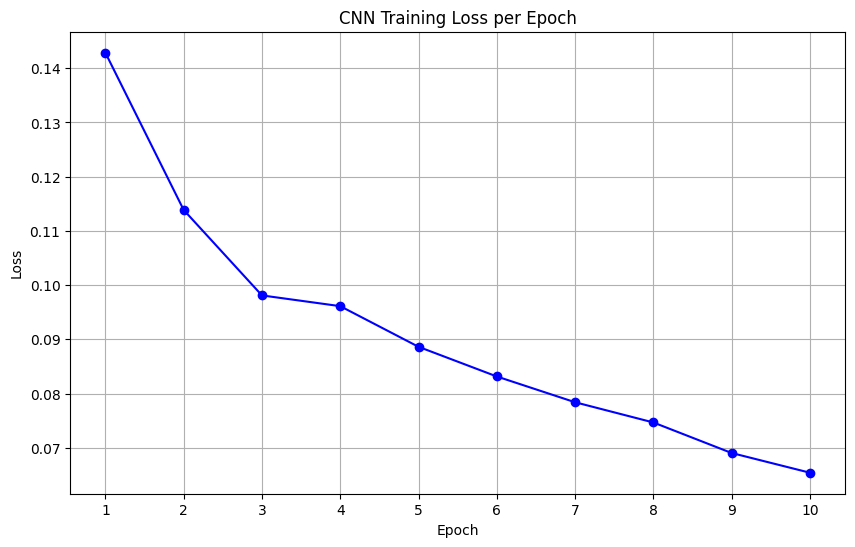

Training loss per epoch plotted.


In [60]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', color='blue')
plt.title('CNN Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, num_epochs + 1))
plt.show()

print("Training loss per epoch plotted.")

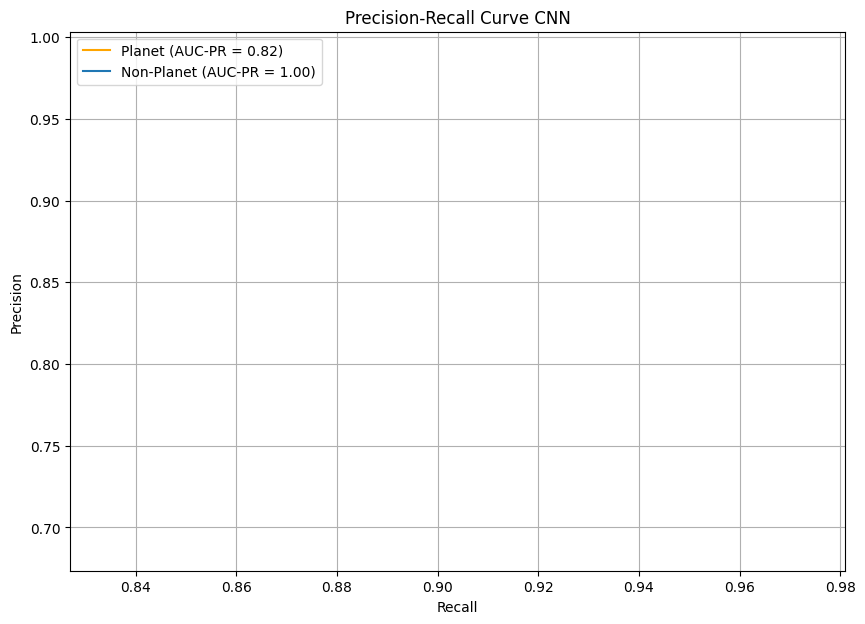

Precision-Recall curves for both classes generated and plotted.


In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))

plt.plot(recall_p, precision_p, label=f'Planet (AUC-PR = {auc_pr_p:.2f})', color = "orange")
plt.plot(recall_np, precision_np, label=f'Non-Planet (AUC-PR = {auc_pr_np:.2f})')

plt.title('Precision-Recall Curve CNN')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend()
plt.grid(True)
plt.show()

print("Precision-Recall curves for both classes generated and plotted.")